# Exercise 1

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from autograd import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from autograd.misc.flatten import flatten_func
from autograd import grad,jacobian
from autograd import value_and_grad, hessian
from autograd.scipy.special import logsumexp
from MLRPlotting import static_plotter
import random as random

In [14]:
#from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
def generate_stripe_image(size, stripe_nr, vertical = True):
    img=np.zeros((size,size,1),dtype="uint8")
    for i in range(0,stripe_nr):
        x,y = np.random.randint(0,size,2)
        l  = int(np.random.randint(y,size,1))
    if (vertical):
        img[y:l,x,0]=255
    else:
        img[x,y:l,0]=255
    return img  

C:\Users\Whatever\AppData\Local\Temp\ipykernel_19580\866079596.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  l  = int(np.random.randint(y,size,1))


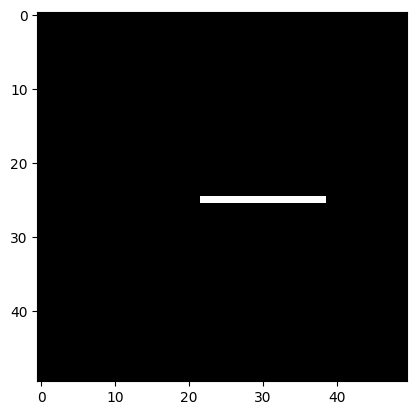

In [4]:

#img=generate_stripe_image(50,10, vertical=True)
img=generate_stripe_image(50,10, vertical=False)
plt.imshow(img[:,:,0],cmap='gray')
#print(img)

## 1.1, 1.2

In [5]:
Y_val= np.concatenate((np.linspace(0,0,500), np.linspace(1,1,500)), axis=0)
random.shuffle(Y_val)
Y_train= np.concatenate((np.linspace(0,0,500), np.linspace(1,1,500)), axis=0)
random.shuffle(Y_train)
X_train=[]
X_val=[]

for x in Y_train:
    if x<0.5:
        X_train.append(generate_stripe_image(50,10, vertical=True))
    else:
        X_train.append(generate_stripe_image(50,10, vertical=False))
for x in Y_val:
    if x<0.5:
        X_val.append(generate_stripe_image(50,10, vertical=True))
    else:
        X_val.append(generate_stripe_image(50,10, vertical=False))

#Normalize
X_train = np.array(X_train) / 255.0
X_val =  np.array(X_val) / 255.0


C:\Users\Whatever\AppData\Local\Temp\ipykernel_19580\866079596.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  l  = int(np.random.randint(y,size,1))


In [13]:
num_classes=2
Y_train = to_categorical(Y_train, num_classes)
Y_val = to_categorical(Y_val, num_classes)

## 1.3.

In [18]:
model = keras.Sequential([
    layers.Conv2D(filters=1, kernel_size=(5,5), activation='linear', padding='same', input_shape=(50,50,1)),
    layers.MaxPooling2D(pool_size=(50,50)),  # This now works
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
optimizer='adam',
metrics=['accuracy'])

There are 5 * 5 * 1+1=26 parameters.

## 1.4.

In [19]:
history=model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True) 

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.4843 - loss: 0.7225 - val_accuracy: 0.4950 - val_loss: 0.7049
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4933 - loss: 0.7045 - val_accuracy: 0.4950 - val_loss: 0.6921
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4934 - loss: 0.6941 - val_accuracy: 0.4950 - val_loss: 0.6812
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5034 - loss: 0.6781 - val_accuracy: 0.4950 - val_loss: 0.6713
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4928 - loss: 0.6710 - val_accuracy: 0.4950 - val_loss: 0.6616
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5158 - loss: 0.6573 - val_accuracy: 0.4950 - val_loss: 0.6519
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5067 - loss: 0.6507 - val_accuracy: 0.4960 - val_loss: 0.6421
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5222 - loss: 0.6349 - val_accuracy: 0.4960 - v

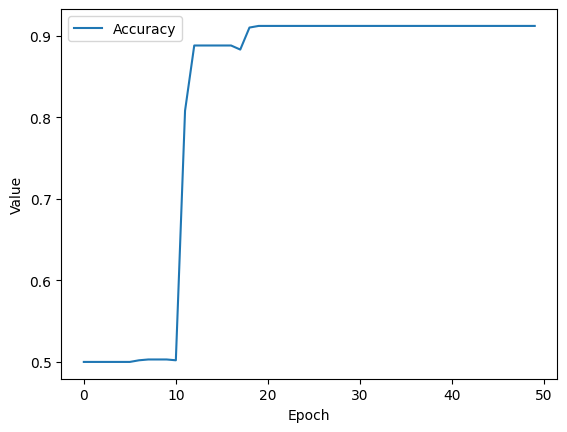

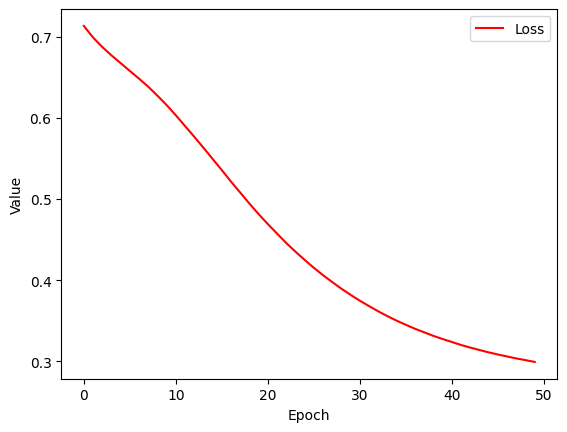

In [24]:
plt.plot(history.history['accuracy'], label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Loss',color='r')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()

## 1.5.

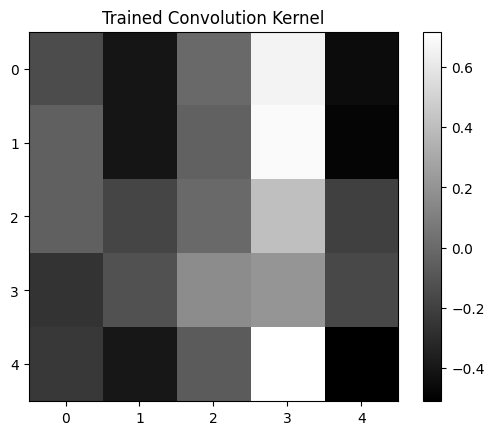

In [49]:
my_kernel = model.get_weights()[0]  # First weight matrix

# Reshape the kernel (assuming it's 5x5 with 1 filter)
kernel = my_kernel[:, :, 0, 0]  # Extract the first (and only) filter

# Plot the kernel as a grayscale image
plt.imshow(kernel, cmap='gray')
plt.colorbar()
plt.title("Trained Convolution Kernel")
plt.show()

In [26]:
Y_pred = model.predict(X_val)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [45]:
res=((np.sign(Y_pred.T-0.5)+1)/2)[0]
miscount=sum((res-Y_val.T[0])**2)
print('the accuracy is:',1-miscount/len(Y_val.T[0]))

the accuracy is: 0.91


The kernel appears to have alternating patterns, so it is likely detecting stripe orientations.
Also, we calculate the accuracy on X_val and Y_val, and 0.91 is a nice result.
## 1.6.

In [50]:
res=((np.sign(Y_pred.T-0.5)+1)/2)[0]
miscount=sum((res-Y_val.T[0])**2)
print('the accuracy is:',1-miscount/len(Y_val.T[0]))

the accuracy is: 0.91


In [52]:
#relu:
model = keras.Sequential([
    layers.Conv2D(filters=1, kernel_size=(5,5), activation='relu', padding='same', input_shape=(50,50,1)),
    layers.MaxPooling2D(pool_size=(50,50)),  # This now works
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
optimizer='adam',
metrics=['accuracy'])

history=model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True) 

Y_pred = model.predict(X_val)
res=((np.sign(Y_pred.T-0.5)+1)/2)[0]
miscount=sum((res-Y_val.T[0])**2)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.4943 - loss: 0.6871 - val_accuracy: 0.4950 - val_loss: 0.6734
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4850 - loss: 0.6758 - val_accuracy: 0.4950 - val_loss: 0.6600
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5078 - loss: 0.6537 - val_accuracy: 0.4950 - val_loss: 0.6471
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5046 - loss: 0.6439 - val_accuracy: 0.4920 - val_loss: 0.6342
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5167 - loss: 0.6260 - val_accuracy: 0.4900 - val_loss: 0.6232
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4925 - loss: 0.6215 - val_accuracy: 0.4900 - val_loss: 0.6116
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.5082 - loss: 0.6088 - val_accuracy: 0.4900 - val_loss: 0.5997
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5302 - loss: 0.5903 - val_accuracy: 0.4990 -

In [58]:
print('the accuracy of relu activation is:',1-miscount/len(Y_val.T[0]))
print('Relu activation improves the accuracy.')

the accuracy of relu activation is: 0.833
Relu activation improves the accuracy.


In [54]:
#average pooling:
model = keras.Sequential([
    layers.Conv2D(filters=1, kernel_size=(5,5), activation='relu', padding='same', input_shape=(50,50,1)),
    layers.AveragePooling2D(pool_size=(50,50)),
    layers.Flatten(),
    layers.Dense(2, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
optimizer='adam',
metrics=['accuracy'])

history=model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=50,
                  verbose=1,
                  shuffle=True) 

Y_pred = model.predict(X_val)
res=((np.sign(Y_pred.T-0.5)+1)/2)[0]
miscount=sum((res-Y_val.T[0])**2)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.4064 - loss: 0.6935 - val_accuracy: 0.3830 - val_loss: 0.6933
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3872 - loss: 0.6933 - val_accuracy: 0.4370 - val_loss: 0.6932
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4717 - loss: 0.6932 - val_accuracy: 0.5030 - val_loss: 0.6932
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4768 - loss: 0.6932 - val_accuracy: 0.5090 - val_loss: 0.6931
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4893 - loss: 0.6931 - val_accuracy: 0.5750 - val_loss: 0.6930
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5721 - loss: 0.6930 - val_accuracy: 0.5340 - val_loss: 0.6930
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5080 - loss: 0.6931 - val_accuracy: 0.5800 - val_loss: 0.6929
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5273 - loss: 0.6929 - val_accuracy: 0.5000 - v

In [59]:
print('the accuracy of average pooling is:',1-miscount/len(Y_val.T[0]))
print('average pooling makes is worse')

the accuracy of average pooling is: 0.833
average pooling makes is worse


A smaller kernel captures finer details but might miss larger stripe patterns.

A larger kernel captures more context but might be less sensitive to small changes.

The choice of kernel size affects the network's ability to generalize.

In [46]:
conv_filter=model.get_weights()[0]

# Exercise 2

In [67]:
datapath=r"C:\Users\Whatever\Desktop"
csvname = datapath + '\multiple_sine_waves.csv'
data = np.loadtxt(csvname,delimiter=',')
x = data[:2,:]
y = data[2:,:]
print(x.shape,y.shape)

(2, 100) (2, 100)


In [118]:
def gradient_descent(g,alpha,max_its,w):
    # compute gradient module using autograd
    gradient = grad(g)

    # run the gradient descent loop
    weight_history = [w]     # container for weight history
    cost_history = [g(w)]    # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_eval = gradient(w)

        # take gradient descent step
        w = w - alpha*grad_eval

        # record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))
    return weight_history,cost_history

def feature_transforms(x,w):
    #print(x.T.shape,w)
    a = w[0] + np.dot(x.T,w[1:])
    return np.sin(a).T

def model(x,w):    
    # feature transformation 
    f = feature_transforms(x,w[0])
    #print(w)
    # compute linear combination and return
    a = w[1][0] + np.dot(f.T,w[1][1:])
    return a.T

def least_squares(w):    
    cost = np.sum((model(x,w) - y)**2)
    return cost/float(np.size(y))

In [119]:
import autograd.numpy as np
g = least_squares
num_feats = 2
w = np.array([np.random.randn(3,num_feats),np.random.randn(num_feats + 1,2)])
print(w)
max_its = 2000;
alpha_choice = 10**(0);
weight_history,cost_history = gradient_descent(g,alpha_choice,max_its,w)


[[[ 0.27118167 -0.79255713]
  [ 0.57460265  0.33658392]
  [ 0.35132759 -1.17639401]]

 [[-1.55199876  0.70669635]
  [-0.54335002 -0.09449432]
  [-0.61181898  1.2866065 ]]]


the optimal parameters are: [[[-1.48373068e-04 -6.28313185e+00]
  [-3.65527778e+00  5.75554654e+00]
  [-8.17190442e+00  5.25013035e+00]]

 [[ 4.10421239e-05  5.97004718e-05]
  [-1.00037702e+00  4.25148849e-04]
  [-6.64611554e-04 -9.99791155e-01]]]


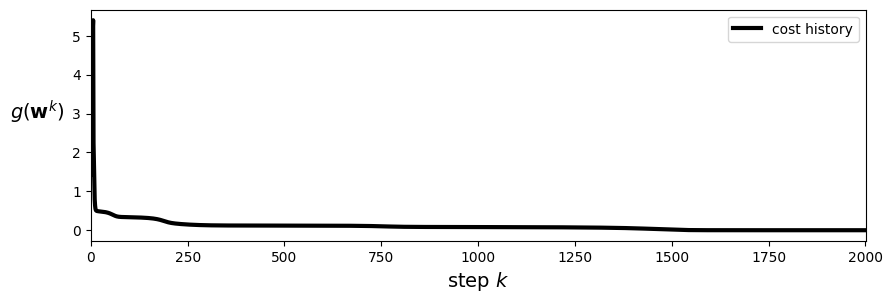

In [121]:
from MLRPlotting import static_plotter
print('the optimal parameters are:',weight_history[np.argmin(cost_history)])

static_plotter = static_plotter.Visualizer();

static_plotter.plot_cost_histories([cost_history],start=0,points=False,labels=['cost history'])

# Exercise 3

In [144]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255
historyl=[]
alpha = 1.
for alpha in [1.,0.5,0.1, 0.01,0.001]:
    model = keras.Sequential([
      layers.Dense(512, activation='relu'),
      layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.RMSprop(alpha),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history=model.fit(train_images, train_labels,
              epochs=10,
              batch_size=128,
              validation_split=0.2)
    historyl.append(history.history['val_loss'])

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3608 - loss: 2669.3906 - val_accuracy: 0.1675 - val_loss: 2.3049
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1640 - loss: 2.4716 - val_accuracy: 0.1377 - val_loss: 2.2780
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1570 - loss: 2.5172 - val_accuracy: 0.1740 - val_loss: 2.3015
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1630 - loss: 2.3643 - val_accuracy: 0.1972 - val_loss: 2.1765
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1862 - loss: 2.3201 - val_accuracy: 0.1916 - val_loss: 2.3739
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1839 - loss: 2.6938 - val_accuracy: 0.1974 - val_loss: 2.1742
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1881 - loss: 2.2232 - val_accuracy: 0.1930 - val_loss: 2.2386
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1974 - loss: 2.2505 - val_a

## 3.1.

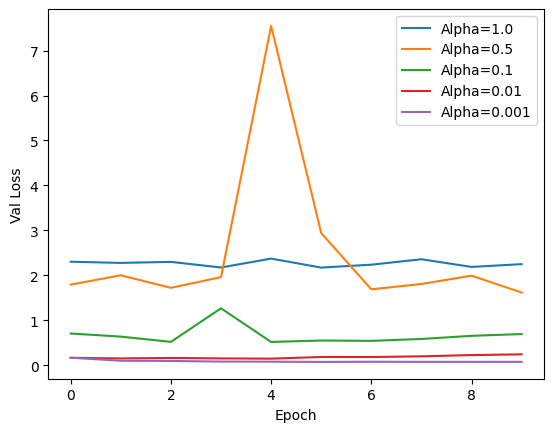

In [151]:
for i in range(5):
    plt.plot(historyl[i], label='Alpha='+str([1.,0.5,0.1, 0.01,0.001][i]))
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend()
plt.show()


As we decrease the value of alpha, the val loss become smaller.It shows that the first choice aplha=1 is not a god choice. The reason is that too large learning rate will make the training unstable.

## 3.2.

In [146]:
model = keras.Sequential([layers.Dense(10, activation='softmax')])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_small_model = model.fit(
    train_images, train_labels,
    epochs=50,
    batch_size=128,
    validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7430 - loss: 1.0369 - val_accuracy: 0.9019 - val_loss: 0.3606
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8981 - loss: 0.3702 - val_accuracy: 0.9143 - val_loss: 0.3100
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9135 - loss: 0.3114 - val_accuracy: 0.9199 - val_loss: 0.2924
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9172 - loss: 0.2994 - val_accuracy: 0.9208 - val_loss: 0.2836
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9160 - loss: 0.2964 - val_accuracy: 0.9235 - val_loss: 0.2788
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9192 - loss: 0.2850 - val_accuracy: 0.9238 - val_loss: 0.2758
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9213 - loss: 0.2786 - val_accuracy: 0.9250 - val_loss: 0.2730
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9242 - loss: 0.2769 - val_accuracy: 0.

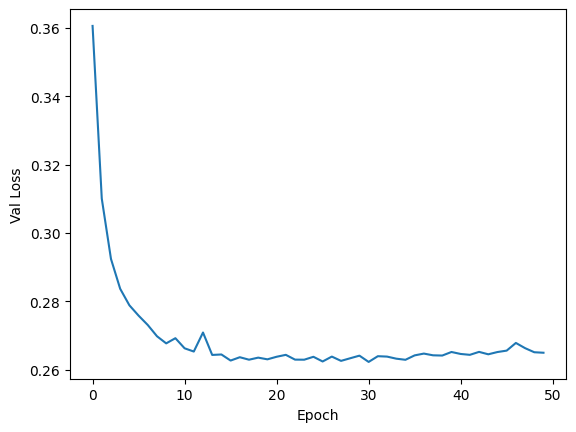

In [152]:
plt.plot(history_small_model.history['val_loss'], label='Val_Loss')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')

plt.show()

The minimum appears at epoch ~ 25. It shows that it goes overfit from the 25th epoch.

## 3.3.

In [148]:
model = keras.Sequential([
  layers.Dense(96, activation='relu'),
  layers.Dense(96, activation='relu'),
  layers.Dense(10, activation='softmax'),
])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_large_model = model.fit(
    train_images, train_labels,
    epochs=50,
    batch_size=128,
    validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8248 - loss: 0.6331 - val_accuracy: 0.9404 - val_loss: 0.1997
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9479 - loss: 0.1750 - val_accuracy: 0.9597 - val_loss: 0.1357
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9641 - loss: 0.1204 - val_accuracy: 0.9665 - val_loss: 0.1143
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9737 - loss: 0.0872 - val_accuracy: 0.9688 - val_loss: 0.1070
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9806 - loss: 0.0671 - val_accuracy: 0.9707 - val_loss: 0.0980
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9825 - loss: 0.0568 - val_accuracy: 0.9727 - val_loss: 0.0980
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accuracy: 0.9728 - val_loss: 0.0962
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9878 - loss: 0.0397 - val_accuracy: 0.

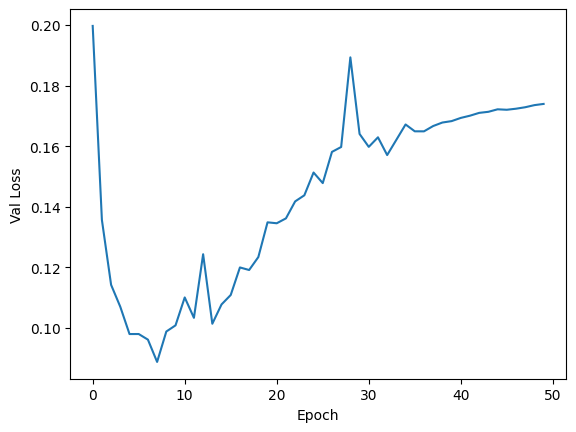

In [154]:
plt.plot(history_large_model.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.show()

There is a clear minimum with a well defined region of overfitting, and it occurs at ~ 7th epoch
# Exercise 4

In [159]:
%pip install --user scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ------ --------------------------------- 1.8/11.1 MB 11.2 MB/s eta 0:00:01
   ---------------- ----------------------- 4.5/11.1 MB 11.7 MB/s eta 0:00:01
   ------------------------- -------------- 7.1/11.1 MB 12.1 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.1 MB 12.3 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 11.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


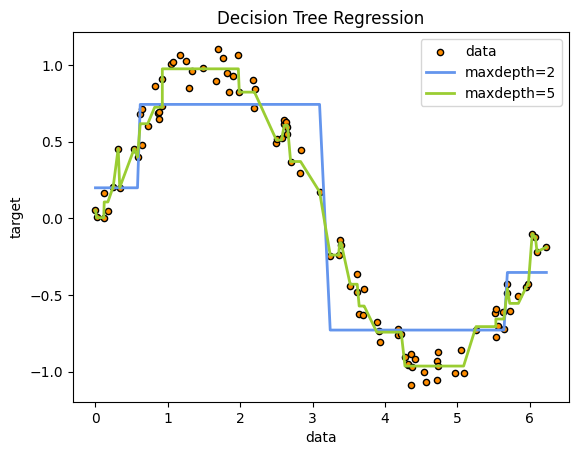

In [160]:
# Import the necessary modules and libraries
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(6.3 * rng.rand(100, 1), axis=0)
y = np.sin(X).ravel()
y += 0.3 * (0.5 - rng.rand(len(X)))
# Fit regression model
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

# Predict
y_1 = regr_1.predict(X)
y_2 = regr_2.predict(X)

# Plot the results
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black",
            c="darkorange", label="data")
plt.plot(X, y_1, color="cornflowerblue",
         label="maxdepth=2", linewidth=2)
plt.plot(X, y_2, color="yellowgreen", label="maxdepth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

In [ ]:
'''def My_TreeRegressor(y,il,ir,max_depth,level=0):
    global yreg
    if (level==0): yreg=np.zeros(len(y))'''

[0.19914523 0.19914523 0.19914523 0.19914523 0.19914523]
[0.05272709 0.00457171 0.00457171 0.10682743 0.10682743]


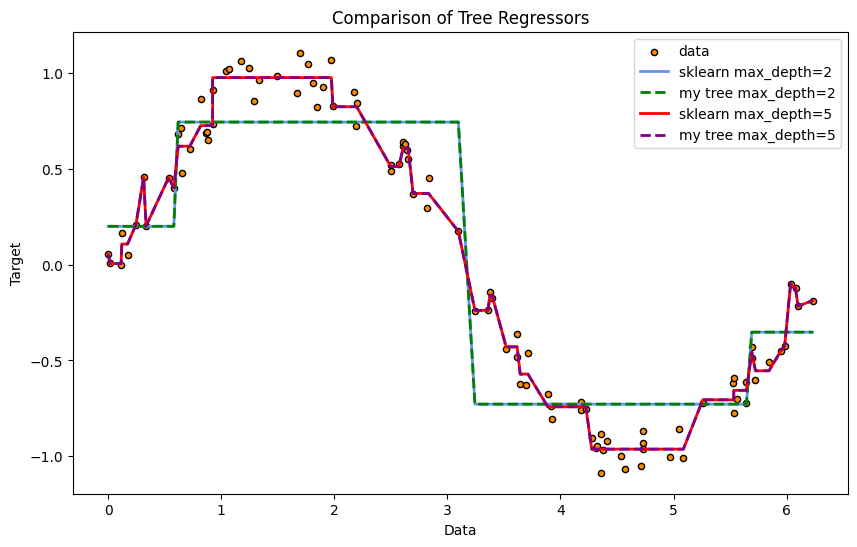

In [162]:
def My_TreeRegressor(y, il, ir, max_depth, level=0):
    global yreg
    if level == 0:
        yreg = np.zeros(len(y))
        
    if ir - il <= 1 or level == max_depth:
        mean_val = np.mean(y[il:ir])
        yreg[il:ir] = mean_val
        return

    best_split = None
    best_cost = np.inf
    for s in range(il+1, ir):
        left_mean = np.mean(y[il:s])
        right_mean = np.mean(y[s:ir])
        cost_left = np.sum((y[il:s] - left_mean)**2)
        cost_right = np.sum((y[s:ir] - right_mean)**2)
        cost = cost_left + cost_right
        if cost < best_cost:
            best_cost = cost
            best_split = s

    if best_split is None:
        mean_val = np.mean(y[il:ir])
        yreg[il:ir] = mean_val
        return

    left_mean = np.mean(y[il:best_split])
    right_mean = np.mean(y[best_split:ir])
    yreg[il:best_split] = left_mean
    yreg[best_split:ir] = right_mean

    My_TreeRegressor(y, il, best_split, max_depth, level + 1)
    My_TreeRegressor(y, best_split, ir, max_depth, level + 1)

My_TreeRegressor(y, 0, len(y), max_depth=2)
y_my_tree_2 = yreg.copy()

My_TreeRegressor(y, 0, len(y), max_depth=5)
y_my_tree_5 = yreg.copy()

regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)

regr_1.fit(X, y)
regr_2.fit(X, y)

y_sklearn_1 = regr_1.predict(X)
y_sklearn_2 = regr_2.predict(X)

print(y_sklearn_1[:5])  
print(y_sklearn_2[:5])

plt.figure(figsize=(10,6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X, y_sklearn_1, color="cornflowerblue", label="sklearn max_depth=2", linewidth=2)
plt.plot(X, y_my_tree_2, color="green", linestyle="--", label="my tree max_depth=2", linewidth=2)
plt.plot(X, y_sklearn_2, color="red", label="sklearn max_depth=5", linewidth=2)
plt.plot(X, y_my_tree_5, color="purple", linestyle="--", label="my tree max_depth=5", linewidth=2)
plt.xlabel("Data")
plt.ylabel("Target")
plt.title("Comparison of Tree Regressors")
plt.legend()
plt.show()

They do agree with each other.